# 02 — Classical Machine Learning: Regularized Logistic Regression

**Goal:** train regression-based classical ML models on each of the three training set sizes (small / medium / large) from
Notebook 01, and record how each performs.


**Concepts applied here:**
- Logistic regression + L2 regularization, hyperparameter tuning via cross-validation
- Feature engineering with polynomial/interaction terms to let a linear model capture non-linear
  decision boundaries
- Bias-variance diagnosis via learning curves, train/validation/test methodology, error analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import time

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
data = joblib.load("../data/processed/tabular_data.joblib")
subsets = data["subsets"]
X_val, y_val = data["X_val"], data["y_val"]
X_test, y_test = data["X_test"], data["y_test"]
n_numeric = len(data["feature_names_numeric"])

for name, (X, y) in subsets.items():
    print(name, X.shape)
print("Number of (scaled) numeric columns at the start of each feature matrix:", n_numeric)

small (800, 108)
medium (6000, 108)
large (34187, 108)
Number of (scaled) numeric columns at the start of each feature matrix: 6


## Helper: train + evaluate any sklearn-style model

One reusable function so every model/dataset-size combination is scored identically.

In [3]:
def evaluate_model(model, X, y):
    """Return standard metrics for a fitted model on data (X, y)."""
    preds = model.predict(X)
    probs = model.predict_proba(X)[:, 1] if hasattr(model, "predict_proba") else preds
    return {
        "accuracy": accuracy_score(y, preds),
        "precision": precision_score(y, preds, zero_division=0),
        "recall": recall_score(y, preds, zero_division=0),
        "f1": f1_score(y, preds, zero_division=0),
        "roc_auc": roc_auc_score(y, probs),
    }

def run_experiment(model_name, estimator, param_grid, subsets_dict, val_X, cv=3):
    """For each training set size: grid-search hyperparameters on that subset (via CV),
    refit best model, evaluate on the fixed validation set, record everything."""
    rows = []
    fitted_models = {}
    for size_name, (X_train, y_train) in subsets_dict.items():
        t0 = time.time()
        search = GridSearchCV(estimator, param_grid, cv=cv, scoring="f1", n_jobs=-1)
        search.fit(X_train, y_train)
        best_model = search.best_estimator_
        best_params = search.best_params_
        train_time = time.time() - t0

        val_metrics = evaluate_model(best_model, val_X, y_val)
        row = {
            "model": model_name,
            "dataset_size_name": size_name,
            "n_train": X_train.shape[0],
            "n_features": X_train.shape[1],
            "train_time_sec": train_time,
            "best_params": str(best_params),
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }
        rows.append(row)
        fitted_models[size_name] = best_model
        print(f"{model_name} | {size_name} (n={X_train.shape[0]}): "
              f"val_f1={val_metrics['f1']:.3f}, val_acc={val_metrics['accuracy']:.3f}, "
              f"time={train_time:.1f}s")
    return rows, fitted_models

## Model 1 — Plain Logistic Regression (+ L2 regularization tuning)

We tune the inverse-regularization strength `C` (smaller C = stronger regularization) via
cross-validated grid search on each training subset.

In [4]:
logreg_grid = {"C": [0.01, 0.1, 1.0, 10.0]}
logreg_rows, logreg_models = run_experiment(
    "LogisticRegression",
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    logreg_grid,
    subsets,
    X_val,
)

LogisticRegression | small (n=800): val_f1=0.623, val_acc=0.839, time=2.6s
LogisticRegression | medium (n=6000): val_f1=0.649, val_acc=0.846, time=2.2s
LogisticRegression | large (n=34187): val_f1=0.642, val_acc=0.845, time=1.3s


## Model 2 — Logistic Regression with Polynomial/Interaction Features

This is the "let a linear model draw a non-linear decision boundary": we expand the **numeric** features into degree-2 polynomial and interaction terms (e.g.
`age^2`, `hours_per_week * age`) before feeding them to logistic regression, then rely on L2
regularization to keep it from overfitting given the extra features. We only expand the numeric
columns (not the one-hot encoded categorical columns) to keep the feature space manageable.

In [5]:
poly = PolynomialFeatures(degree=2, include_bias=False)
poly.fit(X_val[:, :n_numeric])   # fit only determines the shape/combinations, not data-dependent

def to_poly(X):
    return np.hstack([poly.transform(X[:, :n_numeric]), X[:, n_numeric:]])

subsets_poly = {name: (to_poly(X), y) for name, (X, y) in subsets.items()}
X_val_poly = to_poly(X_val)
X_test_poly = to_poly(X_test)

print("Original feature count:", X_val.shape[1])
print("Polynomial-expanded feature count:", X_val_poly.shape[1])

Original feature count: 108
Polynomial-expanded feature count: 129


In [6]:
logreg_poly_grid = {"C": [0.01, 0.1, 1.0, 10.0]}
logreg_poly_rows, logreg_poly_models = run_experiment(
    "LogisticRegression_Polynomial",
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    logreg_poly_grid,
    subsets_poly,
    X_val_poly,
)

LogisticRegression_Polynomial | small (n=800): val_f1=0.632, val_acc=0.840, time=0.1s
LogisticRegression_Polynomial | medium (n=6000): val_f1=0.662, val_acc=0.849, time=0.8s
LogisticRegression_Polynomial | large (n=34187): val_f1=0.665, val_acc=0.853, time=3.9s


## Combine all results into one table

In [7]:
results_classical = pd.DataFrame(logreg_rows + logreg_poly_rows)
results_classical.to_csv("../results/classical_ml_metrics.csv", index=False)
results_classical

,model,dataset_size_name,n_train,n_features,train_time_sec,best_params,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,LogisticRegression,small,800,108,2.570165,{'C': 1.0},0.838974,0.707458,0.557330,0.623484,0.891655
1,LogisticRegression,medium,6000,108,2.154509,{'C': 1.0},0.845524,0.711368,0.596121,0.648665,0.902990
2,LogisticRegression,large,34187,108,1.324182,{'C': 10.0},0.845115,0.718220,0.580148,0.641843,0.904838
3,LogisticRegression_Polynomial,small,800,129,0.125446,{'C': 1.0},0.839656,0.700416,0.576155,0.632238,0.888121
4,LogisticRegression_Polynomial,medium,6000,129,0.778418,{'C': 1.0},0.848799,0.712032,0.617798,0.661576,0.907065
5,LogisticRegression_Polynomial,large,34187,129,3.943300,{'C': 1.0},0.853439,0.734300,0.606959,0.664585,0.910796


## Learning curves (bias-variance diagnosis)

This is the train/validation-score-vs.-training-size diagnosis taught in ML Specialization Course 2
("Advice for Applying Machine Learning"). For the **large** training subset, we plot training vs.
cross-validation score as a function of the number of examples used — a big gap between the two
curves signals high variance (overfitting); both curves plateauing low and close together signals
high bias (underfitting).

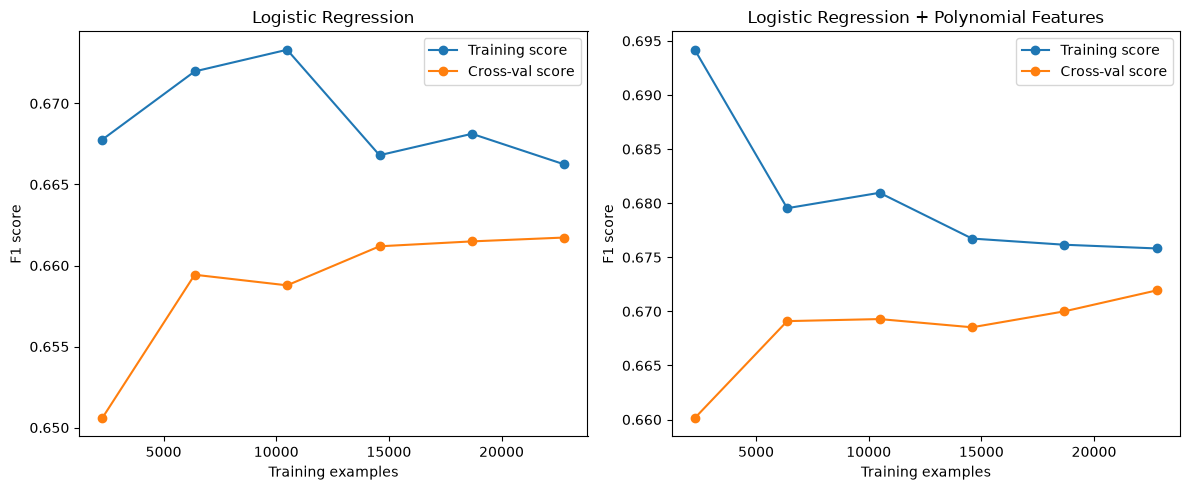

In [8]:
def plot_learning_curve(estimator, X, y, title, ax):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=3, scoring="f1",
        train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1, random_state=RANDOM_STATE
    )
    ax.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Training score")
    ax.plot(train_sizes, val_scores.mean(axis=1), "o-", label="Cross-val score")
    ax.set_title(title)
    ax.set_xlabel("Training examples")
    ax.set_ylabel("F1 score")
    ax.legend()

X_large, y_large = subsets["large"]
X_large_poly, y_large_poly = subsets_poly["large"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_learning_curve(LogisticRegression(max_iter=2000, C=1.0), X_large, y_large,
                     "Logistic Regression", axes[0])
plot_learning_curve(LogisticRegression(max_iter=2000, C=1.0), X_large_poly, y_large_poly,
                     "Logistic Regression + Polynomial Features", axes[1])
plt.tight_layout()
plt.savefig("../results/figures/classical_learning_curves.png", dpi=150)
plt.show()

## Accuracy vs. training set size — the headline chart (classical models)

This is the chart we will later overlay with the neural network results in Notebook 07.

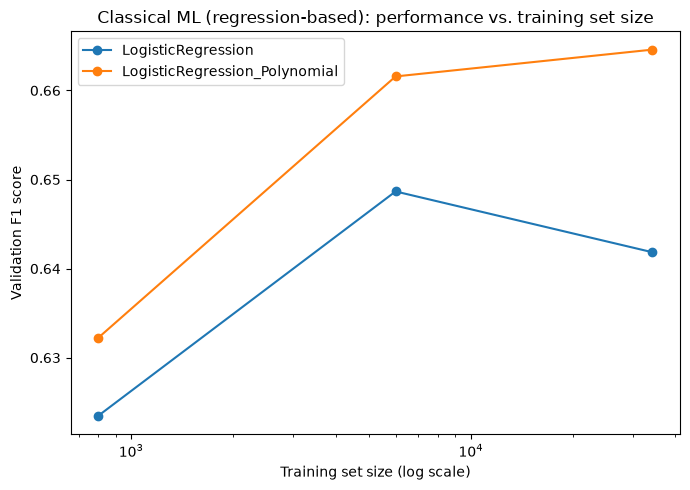

In [9]:
plt.figure(figsize=(7,5))
for model_name in results_classical["model"].unique():
    sub = results_classical[results_classical["model"] == model_name].sort_values("n_train")
    plt.plot(sub["n_train"], sub["val_f1"], marker="o", label=model_name)
plt.xscale("log")
plt.xlabel("Training set size (log scale)")
plt.ylabel("Validation F1 score")
plt.title("Classical ML (regression-based): performance vs. training set size")
plt.legend()
plt.tight_layout()
plt.savefig("../results/figures/classical_f1_vs_size.png", dpi=150)
plt.show()

## Confusion matrix for the best classical model

We pick whichever (model, size) combination had the highest validation F1, then check its
confusion matrix on the held-out test set — the only time we touch the test set in this notebook.

model                LogisticRegression_Polynomial
dataset_size_name                            large
n_train                                      34187
n_features                                     129
train_time_sec                              3.9433
best_params                             {'C': 1.0}
val_accuracy                              0.853439
val_precision                               0.7343
val_recall                                0.606959
val_f1                                    0.664585
val_roc_auc                               0.910796
Name: 5, dtype: object


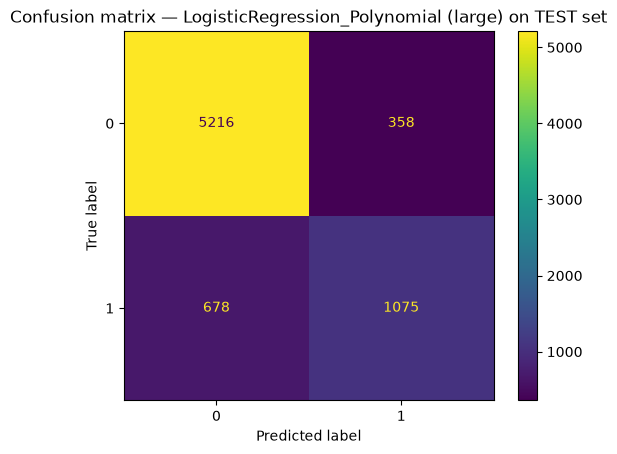

In [10]:
best_row = results_classical.loc[results_classical["val_f1"].idxmax()]
print(best_row)

best_model_map = {"LogisticRegression": logreg_models, "LogisticRegression_Polynomial": logreg_poly_models}
best_model = best_model_map[best_row["model"]][best_row["dataset_size_name"]]
best_test_X = X_test if best_row["model"] == "LogisticRegression" else X_test_poly

test_preds = best_model.predict(best_test_X)
cm = confusion_matrix(y_test, test_preds)
ConfusionMatrixDisplay(cm).plot()
plt.title(f"Confusion matrix — {best_row['model']} ({best_row['dataset_size_name']}) on TEST set")
plt.savefig("../results/figures/best_classical_confusion_matrix.png", dpi=150)
plt.show()

## Summary

We now have validation metrics, learning curves, and a headline "performance vs. data size" chart
for two regression-based classical ML variants (plain logistic regression and logistic regression
with engineered polynomial features) across three training set sizes, saved to
`../results/classical_ml_metrics.csv`.